# Quickstart: ECMWF AIFS deterministic forecast - dynamical.org Icechunk Zarr

ECMWF's Artificial Intelligence Forecasting System (AIFS) is a machine learning weather model that produces global forecasts competitive with traditional physics-based models. It generates 15-day forecasts at 0.25 degree (~25km) resolution every 6 hours.

This dataset provides AIFS deterministic forecasts from April 2024 to present, transformed into a single analysis-ready Zarr store by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ecmwf-aifs-deterministic-forecast/

In [1]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install -q "xarray[complete]>=2025.3.0" "zarr>=3.0.8" icechunk

In [2]:
import icechunk
import xarray as xr

storage = icechunk.s3_storage(bucket="dynamical-aifs-deterministic", prefix="ecmwf-aifs-deterministic-forecast/v0.1.0.icechunk/", region="us-west-2", anonymous=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, chunks=None)
ds

<xarray.Dataset> Size: 12TB
Dimensions:                                     (init_time: 2868,
                                                 lead_time: 61, latitude: 721,
                                                 longitude: 1440)
Coordinates:
    expected_forecast_length                    (init_time) timedelta64[ns] 23kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 23kB ...
  * init_time                                   (init_time) datetime64[ns] 23kB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 1MB ...
Data variables: (12/17)
    dew_point_temperature_2m                    (init_time, lead_time, latitude, longitude) float32 727GB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 727GB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 727GB ...
    geopotential_height_500hpa                  (init_time, lead_time, latitude, longitude) float32 727GB ...
    geopotential_height_850hpa                  (init_time, lead_time, latitude, longitude) float32 727GB ...
    geopotential_height_925hpa                  (init_time, lead_time, latitude, longitude) float32 727GB ...
    ...                                          ...
    temperature_925hpa                          (init_time, lead_time, latitude, longitude) float32 727GB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 727GB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 727GB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 727GB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 727GB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 727GB ...
Attributes:
    dataset_id:           ecmwf-aifs-deterministic-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS deterministic forecast
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS deterministic forecast data processed by...
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~25km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

This is a forecast dataset, so it has two time dimensions: `init_time` (when the forecast was initialized) and `lead_time` (how far ahead the forecast extends). The `valid_time` coordinate combines these to give the actual forecasted time.

AIFS includes upper-atmosphere variables like 500 hPa geopotential height alongside surface fields — let's explore both.

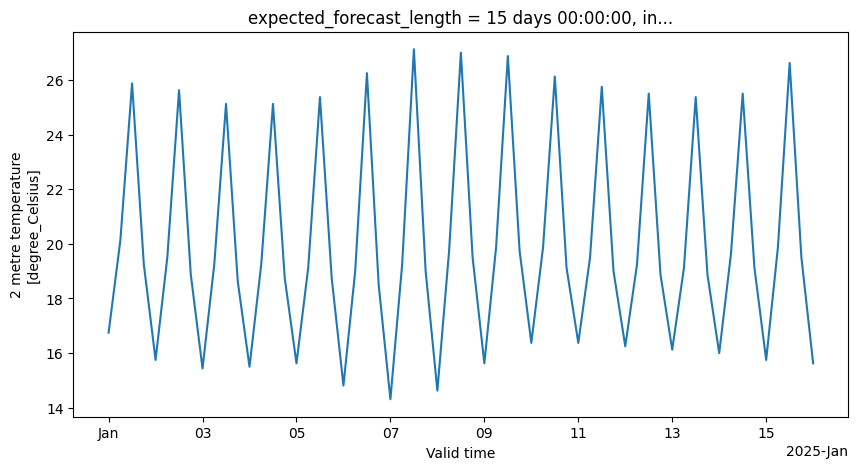

In [3]:
# 15-day temperature forecast for Nairobi, Kenya
plot_ds = ds.sel(init_time="2025-01-01T00", latitude=-1.3, longitude=36.8, method="nearest")
_ = plot_ds["temperature_2m"].plot(x="valid_time", figsize=(10, 5))

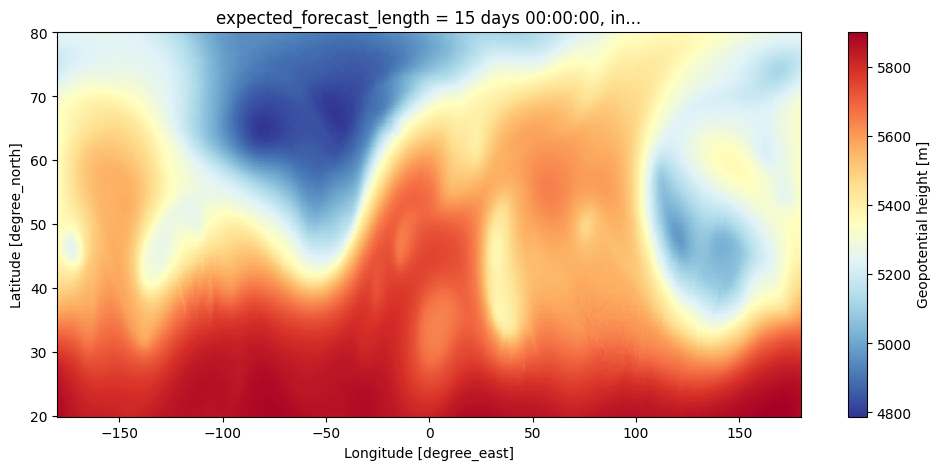

In [4]:
# 500 hPa geopotential height, 5 days ahead — reveals the jet stream and large-scale troughs
(
    ds["geopotential_height_500hpa"]
    .sel(init_time="2025-02-01T00", lead_time="5d")
    .sel(latitude=slice(80, 20))
    .plot(figsize=(12, 5), cmap="RdYlBu_r")
)

### How strong were 100m winds during Storm Éowyn?

Storm Éowyn struck Ireland and the UK on January 24, 2025 with record-breaking winds. We can compute 100m wind speed from the u and v components and map the storm's intensity.

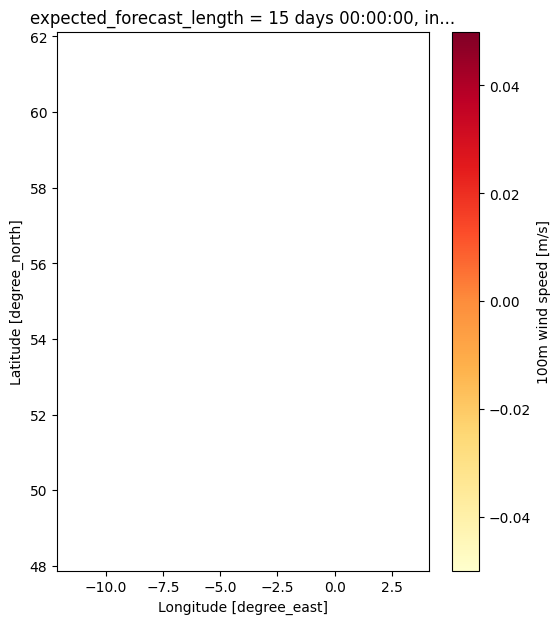

In [5]:
import numpy as np

# 100m wind speed over the British Isles, AIFS forecast initialized Jan 24 00Z, 6 hours ahead
sel = dict(
    init_time="2025-01-24T00",
    lead_time="6h",
    latitude=slice(62, 48),
    longitude=slice(-12, 4),
)

wind_speed = np.sqrt(ds["wind_u_100m"].sel(**sel)**2 + ds["wind_v_100m"].sel(**sel)**2)
wind_speed.attrs["units"] = "m/s"
wind_speed.attrs["long_name"] = "100m wind speed"
wind_speed.plot(figsize=(6, 7), cmap="YlOrRd")

### Where is the coldest temperature forecast in the Northern Hemisphere right now?

Using the most recent forecast initialization, we can find the location with the lowest predicted 2m temperature over the next 24 hours.

In [6]:
import pandas as pd

latest_init = ds.init_time[-1].values

cold_forecast = (
    ds["temperature_2m"]
    .sel(init_time=latest_init, lead_time=slice("6h", "1d"))
    .sel(latitude=slice(70, 30))  # Northern Hemisphere mid-latitudes
    .min(dim="lead_time")
    .load()
)

min_val = float(cold_forecast.min())
min_loc = cold_forecast.argmin(dim=["latitude", "longitude"])
min_lat = float(cold_forecast.latitude[min_loc["latitude"]])
min_lon = float(cold_forecast.longitude[min_loc["longitude"]])

print(f"Coldest 24h forecast: {min_val:.1f} K ({min_val - 273.15:.1f} °C) at latitude {min_lat:.2f}, longitude {min_lon:.2f}")
print(f"Forecast initialized: {pd.Timestamp(latest_init)}")

Coldest 24h forecast: -43.5 K (-316.6 °C) at latitude 70.00, longitude -102.75
Forecast initialized: 2026-03-18 18:00:00


### Animated map

Let's animate 100m wind speed over the North Atlantic as Storm Éowyn develops and sweeps across Ireland.

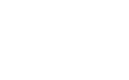

In [7]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

# Animation of 100m wind speed as Storm Éowyn crosses the North Atlantic
wind_u = ds["wind_u_100m"].sel(
    init_time="2025-01-22T00",
    lead_time=slice("0h", "4d"),
    latitude=slice(65, 40),
    longitude=slice(-40, 10),
).load()

wind_v = ds["wind_v_100m"].sel(
    init_time="2025-01-22T00",
    lead_time=slice("0h", "4d"),
    latitude=slice(65, 40),
    longitude=slice(-40, 10),
).load()

wind_speed = np.sqrt(wind_u**2 + wind_v**2)

scale = 0.5
dpi = 150
fig, ax = plt.subplots(
    figsize=(wind_speed.longitude.size * scale / dpi, wind_speed.latitude.size * scale / dpi), dpi=dpi
)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(wind_speed.isel(lead_time=0), cmap="YlOrRd", vmin=0, vmax=35)
anim = FuncAnimation(
    fig=fig, frames=wind_speed, func=lambda frame: img.set_data(frame), interval=200
)

HTML(anim.to_jshtml())

### Community challenge

AIFS is one of a new generation of ML weather models. With global 6-hourly forecasts out to 15 days, there are many avenues to explore.

Here are a few for inspiration:
- How does AIFS forecast skill degrade with lead time? Compare forecasts of the same event initialized at different times — does the 1-day-ahead forecast consistently outperform the 5-day-ahead? Use temperature or wind speed at a set of stations to quantify the error.
- Renewable energy depends on accurate wind and solar radiation forecasts. Use the 100m wind and downward shortwave radiation fields to estimate wind and solar power potential across a region, and explore how forecast uncertainty grows over the 15-day horizon.